### **ChromBPNet Model Evaluations**

**<span style="color: darkred;">This notebook includes visualising the evaluation metrics of the models generated.</span>**

Once the models have been generated, they should be found in the following directories in the **CREATE HPC**:
- _/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/Bias_models/*_
- _/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/Models/*_

While each model generates a separate evaluation pdf, with all metrics identifiable within it, these metrics can be concatenated into table format using the following scripts found within this repository:
- For the Bias models: _Downstream_Analyses/other/extract_bias_metrics.py_
- For the Bias-factorised final models: _Downstream_Analyses/other/extract_model_metrics.py_

Once these have been generated, the files available will be _bias_model_metrics.csv_ and _chrombpnet_metrics.csv_, which are used as input in the following notebook. 

In [9]:
# Libraries
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

#### **Load Metric Files**

In [3]:
bias_metrics = pd.read_csv('/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/evaluation_plots/bias_model_metrics.csv', sep=',')
model_metrics = pd.read_csv('/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/evaluation_plots/chrombpnet_metrics.csv', sep=',')

In [4]:
bias_metrics.head(5)

,model_name,nonpeaks.pearsonr,nonpeaks.mse,peaks.pearsonr,peaks.mse,nonpeaks.median_jsd,nonpeaks.median_norm_jsd,peaks.median_jsd,peaks.median_norm_jsd
0,Tn5_bias_model_experiment_10_bias0.5,-0.07,3.05,-0.51,7.51,0.75,0.06,0.70,0.09
1,Tn5_bias_model_experiment_10_bias0.9,0.00,1.37,-0.36,4.22,0.74,0.06,0.69,0.10
2,Tn5_bias_model_experiment_10_bias1.0,0.05,1.23,-0.28,3.85,0.74,0.06,0.69,0.10
3,Tn5_bias_model_experiment_10_consensuspeaks0.5,-0.03,5.77,-0.39,8.96,0.75,0.05,0.74,0.06
4,Tn5_bias_model_experiment_10_consensuspeaks0.9,-0.04,3.60,-0.40,6.03,0.75,0.06,0.73,0.07


**Tn5 Bias Models Used**
- Tn5_bias_model_fold_0_mm10_AtT20_1.5
- Tn5_bias_model_fold_0_mm10_Lbt2_0.9
- Tn5_bias_model_fold_0_mm10_TaT1_0.9
- Tn5_bias_model_fold_0_mm10_adult_0.5
- Tn5_bias_model_fold_0_mm10_neonatal_0.5
- Tn5_bias_model_fold_0_rn6_GH3_0.9

In [5]:
model_metrics.head(5)

,group,model_name,bias.peaks.pearsonr,bias.peaks.mse,bias.peaks.median_jsd,bias.peaks.median_norm_jsd,model.peaks.pearsonr,model.peaks.mse,model.peaks.median_jsd,model.peaks.median_norm_jsd
0,experiments,experiment_10_AtT20_NEO_model,0.169222,2.962771,0.690720,0.102571,0.779074,0.227105,0.684821,0.110518
1,experiments,experiment_10_AtT20_PAX7_model,0.187584,2.281241,0.705866,0.092928,0.766628,0.214510,0.699496,0.101976
2,experiments,experiment_15_model,0.164469,2.205272,0.671318,0.117593,0.712687,0.092060,0.670104,0.119304
3,experiments,experiment_22_TaT1_model,-0.208398,4.148037,0.670317,0.119260,0.811693,0.270056,0.652335,0.141527
4,experiments,experiment_24_ABS_model,0.225124,5.264223,0.607102,0.186337,0.672934,0.512220,0.543399,0.268285


#### **Plot Bias Model Metrics**

In [6]:
# Set values 
highlight_models = {
    'Tn5_bias_model_fold_0_mm10_AtT20_1.5',
    'Tn5_bias_model_fold_0_mm10_Lbt2_0.9',
    'Tn5_bias_model_fold_0_mm10_adult_0.5',
    'Tn5_bias_model_fold_0_rn6_GH3_0.9',
    'Tn5_bias_model_fold_0_mm10_neonatal_0.5',
    'Tn5_bias_model_experiment_22_bias0.9'
}

fold_trials = {
    'Tn5_bias_model_fold_0_mm10_adult_0.5',
    'Tn5_bias_model_fold_1',
    'Tn5_bias_model_fold_2',
    'Tn5_bias_model_fold_3',
    'Tn5_bias_model_fold_4'
}

rat_fold = {
    'Tn5_bias_model_fold_0_rn6_GH3_0.9'
}
 
metrics = ['nonpeaks.pearsonr', 'peaks.pearsonr', 'nonpeaks.median_jsd', 'peaks.median_jsd']

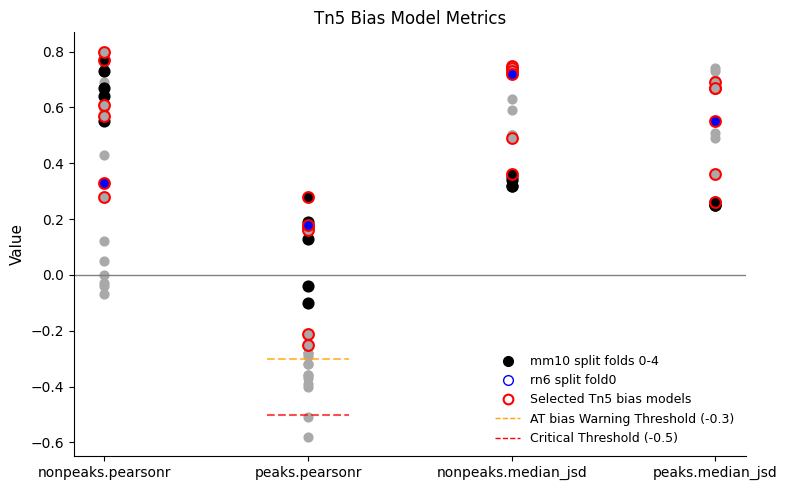

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
 
jitter_strength = 0.08

for _, row in bias_metrics.iterrows():
    is_fold = row['model_name'] in fold_trials
    is_rat_fold = row['model_name'] in rat_fold
    is_highlight = row['model_name'] in highlight_models
    
    # Base group color (facecolor)
    if is_rat_fold:
        facecolor = 'blue'
    elif is_fold:
        facecolor = 'black'
    else:
        facecolor = 'darkgrey'
    
    # Highlight configuration (red outline)
    edgecolor = 'red' if is_highlight else facecolor
    linewidth = 1.5 if is_highlight else 1.0
    zorder = 3 if is_highlight else 2
    size = 60 if (is_fold or is_highlight or is_rat_fold) else 40
 
    for i, metric in enumerate(metrics):
        x = i + (pd.Series([0]).sample(1, random_state=hash(row['model_name']) % 1000).values[0] * jitter_strength)
        
        ax.scatter(x, row[metric], 
                   facecolors=facecolor, 
                   edgecolors=edgecolor, 
                   linewidths=linewidth,
                   s=size,
                   zorder=zorder, 
                   alpha=1.0)
 
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Tn5 Bias Model Metrics', fontsize=12)

ax.axhline(0, color='gray', linewidth=1, linestyle='-', alpha=1)

line_orange = ax.hlines(y=-0.3, xmin=0.8, xmax=1.2, color='orange', 
                        linewidth=1.5, linestyle='--', alpha=0.7)
line_red = ax.hlines(y=-0.5, xmin=0.8, xmax=1.2, color='red', 
                     linewidth=1.5, linestyle='--', alpha=0.7)

#ax.axhline(-0.3, color='orange', linewidth=0.5, linestyle='--', alpha=0.5)
#ax.axhline(-0.5, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
 
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black',
           markersize=7, label='mm10 split folds 0-4'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='blue',
           markersize=7, label='rn6 split fold0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='red',
           markeredgewidth=1.5, markersize=7, label='Selected Tn5 bias models'),
    Line2D([0], [0], color='orange', linewidth=1.0, linestyle='--', label='AT bias Warning Threshold (-0.3)'),
    Line2D([0], [0], color='red', linewidth=1.0, linestyle='--', label='Critical Threshold (-0.5)')
]
ax.legend(handles=legend_elements, fontsize=9, frameon=False, loc='lower right')
 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
#plt.savefig("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/evaluation_plots/bias_model_metrics.svg", format='svg', bbox_inches='tight')
plt.show()

#### **Plot ChromBPNet Model Metrics**

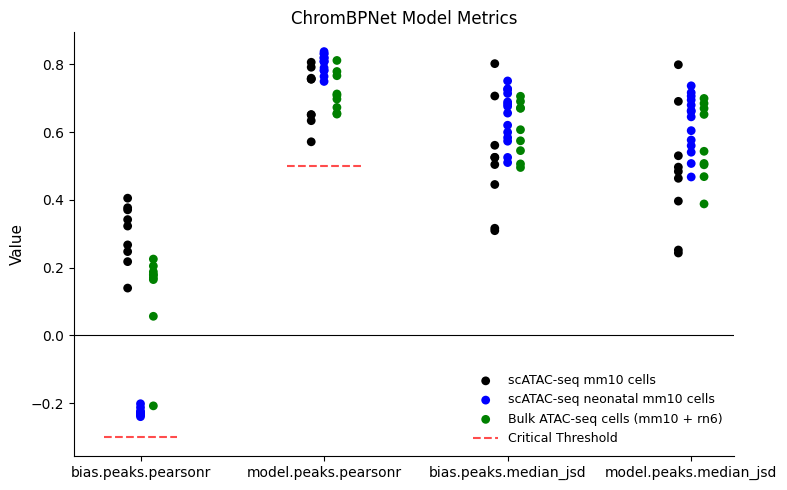

In [12]:
metrics = ['bias.peaks.pearsonr', 'model.peaks.pearsonr', 'bias.peaks.median_jsd', 'model.peaks.median_jsd']
group_offsets = {'mouse': -0.07, 'mouse_young': 0.0, 'experiments': 0.07}

fig, ax = plt.subplots(figsize=(8, 5))

# 1. Plot the metrics side-by-side using group offsets
for group, offset in group_offsets.items():
    sub_df = model_metrics[model_metrics['group'] == group]
    
    for i, metric in enumerate(metrics):
        x = i + offset
        
        # Apply distinct face vs outline colors based on the group name
        if group == 'mouse':
            ax.scatter([x]*len(sub_df), sub_df[metric], facecolors='black', edgecolors='none', s=40, label='scATAC-seq mm10 cells' if i==0 else "")
        elif group == 'mouse_young':
            ax.scatter([x]*len(sub_df), sub_df[metric], facecolors='blue', edgecolors='none', linewidths=1.5, s=40, label='scATAC-seq neonatal mm10 cells' if i==0 else "")
        elif group == 'experiments':
            ax.scatter([x]*len(sub_df), sub_df[metric], facecolors='green', edgecolors='none', linewidths=1.5, s=40, label='Bulk ATAC-seq cells (mm10 + rn6)' if i==0 else "")

# 2. Standard plot formatting
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('ChromBPNet Model Metrics', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8)


#ax.axhline(-0.3, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
#ax.axhline(0.5, color='red', linewidth=0.5, linestyle='--', alpha=0.5)

line_orange = ax.hlines(y=-0.3, xmin=-0.2, xmax=0.2, color='red', 
                        linewidth=1.5, linestyle='--', alpha=0.7)
line_red = ax.hlines(y=0.5, xmin=0.8, xmax=1.2, color='red', 
                     linewidth=1.5, linestyle='--', alpha=0.7)

# Add legend labels
handles, labels = ax.get_legend_handles_labels()
threshold_legend_line = Line2D([0], [0], color='red', linewidth=1.5, linestyle='--', alpha=0.7)
handles.append(threshold_legend_line)
labels.append('Critical Threshold')
ax.legend(handles=handles, labels=labels, fontsize=9, frameon=False, loc='lower right')
# ax.legend(fontsize=9, frameon=False, loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/evaluation_plots/chrombpnet_metrics.svg", format='svg', bbox_inches='tight')
plt.show()